<a href="https://colab.research.google.com/github/karagoz-matias/Data-Science-WPO/blob/main/Task_ADS_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is the impact of connectivity issues on customer churn?

#Selected Business Case
**What is the question we want to answer?**

For this task, we adopt a deep-dive analytical approach, focusing on a single treatment variable while excluding other related technical issue variables to avoid multicollinearity. Specifically, we investigate the following research question: “What is the impact of Wi-Fi coverage issues on customer churn?”
The objective is to estimate the causal effect of the intensity of Wi-Fi coverage issues, measured by the number of days with poor coverage, on the likelihood of customer churn. In addition, we aim to understand how this relationship is influenced by key confounding factors, including customer characteristics, customer environment, usage behavior, and technical setup, all of which may affect both the occurrence of coverage issues and churn.
Ultimately, the goal is to derive actionable insights that enable Telenet to identify and prioritize customers who are most at risk and most responsive to targeted interventions.
To formalize the assumed causal structure, we construct a Directed Acyclic Graph (DAG), which captures the relationships between the treatment, outcome, and relevant covariates. The specific variables included under each confounder category are detailed in the accompanying Excel worksheet.

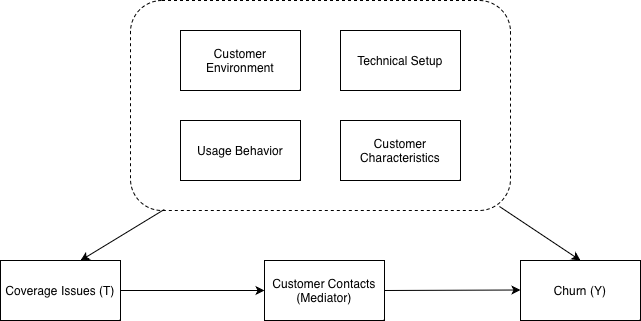

**Why does it matter for Telenet?**

We argue that this research question is highly relevant for Telenet for several reasons. First, it aligns closely with Telenet’s strategic objective of maximizing uplift, which refers to identifying the most effective actions and targeting the right customers in order to improve customer retention. Rather than focusing solely on predicting which customers are likely to churn, as is common in traditional machine learning approaches, this analysis aims to determine which customers are most likely to respond positively to specific interventions, such as resolving Wi-Fi coverage issues.
In this context, the goal is to identify the subset of customers for whom addressing coverage problems would have the greatest impact on reducing churn, thereby enabling more efficient and targeted resource allocation.
From a business perspective, this focus is further justified by well-established insights from the data science and marketing literature. Customer churn represents a significant opportunity cost, as acquiring new customers is substantially more expensive, often estimated to be up to five times, than retaining existing ones. Consequently, reducing churn contributes directly to long-term profitability.
By addressing this research question, Telenet can derive actionable insights that support the optimization of intervention strategies. More specifically, the company can (i) prioritize customers who are most sensitive to connectivity issues, (ii) allocate resources more efficiently, and (iii) reduce churn by acting both proactively (before dissatisfaction escalates) and reactively (in response to detected issues).

**Why did we select this angle?**

We selected this analytical approach because we believe that a deep-dive analysis offers several advantages compared to a broader, more general approach. First, it enables a more precise understanding of the underlying causal mechanisms driving customer churn. Second, it is better suited for the application of causal inference methods, as it allows for a clearer definition of the treatment, outcome, and relevant confounding factors. Third, the focused nature of the analysis provides greater flexibility to develop more creative and insightful solutions. Finally, it facilitates the generation of more actionable recommendations, as the results can be directly translated into specific operational interventions.

In addition, the choice of this research angle is motivated by the evaluation criteria of the assignment. A deep-dive approach allows us to apply the causal inference concepts covered in the course in a more rigorous and coherent manner. In contrast, a broader approach would primarily lead to a high-level strategic overview of which technical issues are most important, but would limit the depth of causal analysis.
By narrowing the scope to a single, well-defined problem, we are able to more effectively implement the methodological framework introduced in class, explore more innovative analytical perspectives, and ultimately derive practical and implementable insights for Telenet.

# Assumptions
**1.	What are the causal assumptions we make?**

In order to identify a causal effect, we rely on a set of standard assumptions from the causal inference framework. First, we note that a randomized controlled trial (RCT) is not feasible in this context, as we work with observational data and have no control over the data-generating process or the assignment of the treatment. Consequently, we adopt an identification strategy based on observational assumptions, namely unconfoundedness (conditional exchangeability), positivity, consistency, and no interference.

The first and most critical assumption is unconfoundedness, which states that, conditional on a set of observed covariates, the treatment assignment is independent of the potential outcomes. In practice, this implies that we control for all relevant confounding variables that influence both Wi-Fi coverage issues and customer churn. Within our framework, this is operationalized by including customer characteristics, usage behavior, technical setup, and environmental proxies in the DAG, thereby aiming to satisfy the backdoor criterion. Under this assumption, conditioning on this set of covariates allows us to obtain an unbiased estimate of the average treatment effect (ATE). We acknowledge that this is a strong assumption, as unobserved confounding may still be present; however, given the limitations of the available dataset, it represents a reasonable and necessary approximation.
Second, we assume positivity, meaning that for every combination of covariates, there is a non-zero probability of observing different levels of the treatment (i.e., different intensities of Wi-Fi coverage issues). This assumption ensures that meaningful comparisons can be made across treatment levels and is required for the estimation of both ATE and conditional average treatment effects (CATE).

Third, we assume no interference, also referred to as the Stable Unit Treatment Value Assumption (SUTVA). This implies that the outcome of one customer is not affected by the treatment assigned to another customer. While this assumption may be violated in practice, for example, due to shared network infrastructure or local congestion effects, it is necessary to simplify the analysis and is commonly adopted in similar settings.

Finally, we assume consistency, which states that the observed outcome for each customer corresponds to the potential outcome under the treatment level they actually experienced. In other words, the treatment is well-defined and consistently measured. We recognize that this assumption may be challenged by the presence of related technical issues that are highly correlated with Wi-Fi coverage, which could blur the interpretation of the treatment. Nevertheless, by clearly defining our treatment variable and excluding overlapping technical indicators, we aim to approximate this assumption as closely as possible

**2. What are important limitations?**

The main limitations of this analysis are directly related to the strength of the causal assumptions required for identification.

First, we rely on the assumption of unconfoundedness, which implies that the set of covariates included in our adjustment set is sufficiently rich to capture all relevant factors that jointly influence both the treatment (Wi-Fi coverage issues) and the outcome (customer churn). In practice, this assumption is unlikely to hold perfectly. Important variables such as housing characteristics (e.g., apartment versus house), building materials, router placement and local network environment are not observed in the dataset and may confound the relationship between coverage issues and churn. As a result, the estimated effects should be interpreted with caution, as some degree of bias due to unobserved confounding may remain. Nevertheless, given the constraints of the available data, we attempt to approximate this assumption as closely as possible by including a comprehensive set of observable covariates.

Second, we assume no interference between units (SUTVA), meaning that one customer’s treatment does not affect another customer’s outcome. While this assumption is standard, it may be violated in practice. For example, customers sharing the same local network infrastructure may experience correlated connectivity issues, which could indirectly affect each other’s service quality and churn behavior. This potential dependence across observations may introduce additional complexity that is not fully captured in our analysis.

Finally, the consistency assumption may also be challenged in this context. This assumption requires that the treatment is well-defined and that the observed outcome corresponds to the potential outcome under the observed treatment level. However, Wi-Fi coverage issues are often intertwined with other technical problems (such as interference or hardware limitations), which may act as alternative or overlapping sources of poor connectivity. This creates ambiguity in the interpretation of the treatment and may blur the distinction between different underlying causes of churn. Consequently, while we define the treatment as clearly as possible, the estimated effect should be interpreted as the impact of overall experienced coverage issues rather than a perfectly isolated causal factor.


**3. What can the analysis establish and what can't it?**

With this analysis, we aim to assess whether there exists a causal relationship between Wi-Fi coverage issues and customer churn. Beyond establishing this relationship, the objective is to derive actionable insights that enable Telenet to better understand which customers are most affected by connectivity problems and therefore most at risk of churning.

While the dataset does not contain detailed information on specific interventions or their outcomes, it does include information on customer contacts, which can be interpreted as a proxy for customer frustration and service interaction. As such, the analysis focuses on understanding how the intensity of Wi-Fi coverage issues influences churn, rather than estimating the causal impact of specific actions taken by Telenet.
The goal is therefore to move beyond purely predictive modeling and toward a more behavior-oriented understanding of churn, by identifying which customer segments are most sensitive to connectivity issues. This allows Telenet to prioritize its efforts by targeting customers who are most likely to be negatively impacted by poor coverage and who may benefit the most from timely intervention.

At the same time, we acknowledge that this analysis has important limitations. In particular, it does not allow us to directly estimate the effectiveness of specific interventions, nor to fully capture how different actions would influence customer behavior. As such, the results should be interpreted as providing directional insights into the drivers of churn, rather than precise estimates of intervention effects.
The analysis pursues two main objectives.

First, within the population of customers experiencing Wi-Fi coverage issues (i.e., customers with a positive number of red coverage days), we aim to identify which individuals are most sensitive to churn within a six-month horizon. This is assessed by examining how the relationship between coverage issues and churn varies across observable characteristics, including confounders and relevant behavioral factors. The objective is to support Telenet in prioritizing customers who are most at risk and most responsive to coverage-related issues, thereby enabling a more efficient allocation of resources.

Second, we investigate the role of customer contacts as a potential mediator in the relationship between Wi-Fi coverage issues and churn. Specifically, we aim to understand to what extent customer interactions with support services reflect underlying dissatisfaction and contribute to the churn process. This allows us to explore how intermediate behavioral responses may influence churn outcomes and to assess how Telenet’s interactions with customers could indirectly affect retention.


# Analysis
**Data preprocessing**

The preprocessing pipeline is designed to support a causal inference analysis by explicitly accounting for the underlying causal structure of the problem. The treatment variable is defined as NUM_DAYS_RED_COVERAGE, which measures the number of days a customer experienced poor Wi-Fi coverage, while the outcome variable is the binary churn indicator. All other variables are first classified based on their causal role. In particular, customer characteristics (CUS_LIFETIME, CUS_LIFESTAGE, and product flags such as CUS_FL_INT, CUS_FL_TEL, etc.), usage behavior variables (INT_VOL_TOT, INT_VOL_DOWN, INT_VOL_STREAMING, INT_USAGE_DAYS, INT_HITMONTHS_*), technical setup variables (INT_NR_LINES, INT_NR_VOLBLOCKS), and environmental proxies (CUS_NR_ADDRESS_*) are treated as confounders, as they influence both coverage issues and churn. In contrast, customer contact variables (NR_TOT_CONT_*) are treated as mediators and are excluded from the main model to avoid post-treatment bias.
A key preprocessing step concerns the operationalization of the treatment variable. Rather than reducing NUM_DAYS_RED_COVERAGE to a binary indicator, it is transformed into an ordinal severity measure with categories such as: no exposure (0 days), mild exposure (1–7 days), moderate exposure (8–14 days), and severe exposure (15+ days). This allows us to capture the intensity of coverage issues and to analyze potential threshold or nonlinear effects on churn.
Handling of missing data is particularly relevant for the variable CUS_LIFESTAGE, which contains missing values. These are imputed using the modal category, and an additional binary indicator is created to flag missing observations. This approach preserves potential information contained in the missingness pattern while ensuring that all observations remain usable in the analysis.
Several variables require distributional transformations. The internet usage variables (INT_VOL_TOT, INT_VOL_DOWN, INT_VOL_UP, INT_VOL_STREAMING, etc.) exhibit strong right-skewness due to heavy users. To reduce the influence of extreme values and improve model stability, a log-transformation of the form log(x + 1) is applied. In addition, the technical issue variables (NUM_DAYS_RED_ excluding the treatment*) are highly zero-inflated. For these variables, two features are created: a binary indicator capturing whether the issue occurred at all, and a log-transformed variable capturing the intensity conditional on occurrence. This allows the model to distinguish between the presence and severity of technical problems.
To address multicollinearity, which is particularly relevant for the technical variables (NUM_DAYS_RED_WIFI_CHANNEL_INTERFERENCE, NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT, NUM_DAYS_RED_MODEM_*, etc.), pairwise correlations are analyzed. Highly correlated variables are either excluded or combined using dimensionality reduction techniques such as principal component analysis (PCA), ensuring that overlapping information does not destabilize the estimation.
Further preprocessing includes the removal of near-zero variance variables, such as INT_USAGE_DAYS if it shows little variation across customers, as well as the exclusion of identifier variables like CUSTOMERNUMBER_anon to prevent data leakage. All continuous variables are then standardized to have zero mean and unit variance, which improves numerical stability in estimation procedures.
Finally, the preprocessing pipeline includes a check of the positivity (overlap) assumption, by inspecting whether customers with similar covariates exhibit variation in treatment levels. Observations in regions with no overlap are excluded or handled carefully to ensure valid causal comparisons. Together, these steps ensure that the dataset is appropriately prepared for causal estimation while aligning with the assumptions required for identifying the effect of Wi-Fi coverage issues on churn.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# CONFIGURATION
# =============================================================================

# --- Column definitions (aligned with variable dictionary) ---

ID_COL = "CUSTOMERNUMBER_anon"
TARGET_COL = "target"
TREATMENT_COL = "NUM_DAYS_RED_COVERAGE"

CATEGORICAL_COLS = ["CUS_LIFESTAGE"]

# Confounders: customer characteristics
CUSTOMER_CONFOUNDERS = [
    "CUS_LIFETIME",
    "CUS_FL_ATV", "CUS_FL_DTV", "CUS_FL_INT", "CUS_FL_MINT",
    "CUS_FL_MTEL", "CUS_FL_TEL", "CUS_FL_MULTI_ADDRESS",
]

# Confounders: address-level churn history
ADDRESS_CONFOUNDERS = [
    "CUS_NR_ADDRESS_TOTAL_CHURN",
    "CUS_NR_ADDRESS_COMM_CHURN",
    "CUS_NR_ADDRESS_FIN_CHURN",
    "CUS_NR_ADDRESS_NON_ORG_CHURN",
    "CUS_NR_ADDRESS_PORT_OUT",
]

# Confounders: internet usage behavior
USAGE_CONFOUNDERS = [
    "INT_NR_LINES",
    "INT_FL_VOLBLOCK",
    "INT_NR_VOLBLOCKS",
    "INT_HITMONTHS_1M", "INT_HITMONTHS_3M",
    "INT_HITMONTHS_6M", "INT_HITMONTHS_1YR",
    "INT_LASTUSAGE",
    "INT_USAGEDAYS",
]

# Confounders: internet volume (will be log-transformed)
VOLUME_COLS = [
    "INT_VOL_TOT",
    "INT_VOL_DOWN",
    "INT_VOL_UP",
    "INT_VOL_STREAMING",
    "INT_VOL_HTTP",
    "INT_VOL_FTP",
]

# Potential mediators — excluded from primary PS model
MEDIATOR_COLS = [
    "NR_TOT_CONT_LM",
    "NR_TOT_CONT_3M",
    "NR_TOT_CONT_6M",
    "NR_TOT_CONT_12M",
]

# Technical confounders with multicollinearity risk (zero-inflated)
TECHNICAL_RED_COLS = [
    "NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT",
    "NUM_DAYS_RED_DEPRECATED_MODEM",
    "NUM_DAYS_RED_DICE",
    "NUM_DAYS_RED_DROPCABLE",
    "NUM_DAYS_RED_FILTER_HP47",
    "NUM_DAYS_RED_FILTER_TOF",
    "NUM_DAYS_RED_MODEM_DEREGS",
    "NUM_DAYS_RED_MODEM_FIT",
    "NUM_DAYS_RED_NETWORK_CAPACITY",
    "NUM_DAYS_RED_PWL_INTERFERENCE",
    "NUM_DAYS_RED_WIFI_CHANNEL_INTERFERENCE",
    "NUM_DAYS_RED_WIFI_CLIENT_CAPACITY",
]

# Thresholds
NEAR_ZERO_VAR_THRESHOLD = 0.95   # Drop if >95% same value
COLLINEARITY_THRESHOLD  = 0.70   # Flag pairs above this correlation
PCA_VARIANCE_THRESHOLD  = 0.80   # Retain components explaining 80% variance


# =============================================================================
# STEP 0 — Load data
# =============================================================================

def load_data(filepath: str) -> pd.DataFrame:
    """Load the dataset from CSV (or Parquet — adjust as needed)."""
    print("=" * 70)
    print("STEP 0 — Loading data")
    print("=" * 70)

    if filepath.endswith(".parquet"):
        df = pd.read_parquet(filepath)
    else:
        df = pd.read_csv(filepath)

    print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Target distribution:\n{df[TARGET_COL].value_counts(normalize=True).round(4)}\n")
    return df


# =============================================================================
# STEP 1 — Drop identifier column
# =============================================================================

def drop_identifier(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 1 — Removing identifier column")
    print("=" * 70)

    if ID_COL in df.columns:
        df = df.drop(columns=[ID_COL])
        print(f"  Dropped: {ID_COL}\n")
    else:
        print(f"  Column '{ID_COL}' not found — skipping.\n")
    return df


# =============================================================================
# STEP 2 — Handle missing values in CUS_LIFESTAGE
# =============================================================================

def handle_missing_lifestage(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 2 — Missing value handling (CUS_LIFESTAGE)")
    print("=" * 70)

    col = "CUS_LIFESTAGE"
    if col not in df.columns:
        print(f"  Column '{col}' not found — skipping.\n")
        return df

    n_missing = df[col].isna().sum()
    pct_missing = n_missing / len(df) * 100
    print(f"  Missing values: {n_missing:,} ({pct_missing:.2f}%)")

    # Create binary missingness indicator
    df[f"{col}_MISSING"] = df[col].isna().astype(int)
    print(f"  Created binary flag: {col}_MISSING")

    # Impute with modal category
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  Imputed with mode: '{mode_val}'\n")

    return df


# =============================================================================
# STEP 3 — One-hot encode CUS_LIFESTAGE
# =============================================================================

def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 3 — One-hot encoding categorical variables")
    print("=" * 70)

    for col in CATEGORICAL_COLS:
        if col not in df.columns:
            print(f"  Column '{col}' not found — skipping.")
            continue

        levels = df[col].value_counts()
        print(f"  {col} levels:\n{levels.to_string()}")

        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df.drop(columns=[col]), dummies], axis=1)
        print(f"  Created {dummies.shape[1]} dummy column(s): {list(dummies.columns)}\n")

    return df


# =============================================================================
# STEP 4 — Log-transform skewed volume variables
# =============================================================================

def log_transform_volumes(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 4 — Log(x+1) transformation of internet volume variables")
    print("=" * 70)

    existing = [c for c in VOLUME_COLS if c in df.columns]
    for col in existing:
        original_skew = df[col].skew()
        df[f"log_{col}"] = np.log1p(df[col])
        new_skew = df[f"log_{col}"].skew()
        print(f"  {col}: skew {original_skew:.2f} → {new_skew:.2f}")

    # Drop originals after transformation
    df = df.drop(columns=existing)
    print(f"\n  Dropped originals; retained log_ variants.\n")
    return df


# =============================================================================
# STEP 5 — Two-part encoding of zero-inflated technical RED variables
# =============================================================================

def encode_zero_inflated_technical(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 5 — Two-part encoding of zero-inflated technical confounders")
    print("=" * 70)

    existing = [c for c in TECHNICAL_RED_COLS if c in df.columns]
    for col in existing:
        pct_zero = (df[col] == 0).mean() * 100
        df[f"flag_{col}"] = (df[col] > 0).astype(int)
        df[f"log_{col}"]  = np.log1p(df[col])
        print(f"  {col}: {pct_zero:.1f}% zeros → flag + log magnitude created")

    # Drop originals
    df = df.drop(columns=existing)
    print(f"\n  Dropped originals; retained flag_ and log_ variants.\n")
    return df


# =============================================================================
# STEP 6 — Remove near-zero variance features
# =============================================================================

def remove_near_zero_variance(df: pd.DataFrame,
                               exclude: list = None) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 6 — Removing near-zero variance features")
    print("=" * 70)

    exclude = exclude or [TARGET_COL, TREATMENT_COL]
    feature_cols = [c for c in df.columns if c not in exclude]

    to_drop = []
    for col in feature_cols:
        top_freq = df[col].value_counts(normalize=True).iloc[0]
        if top_freq >= NEAR_ZERO_VAR_THRESHOLD:
            to_drop.append((col, round(top_freq * 100, 1)))

    if to_drop:
        print(f"  Dropping {len(to_drop)} near-zero variance column(s):")
        for col, pct in to_drop:
            print(f"    {col}: {pct}% identical values")
        df = df.drop(columns=[c for c, _ in to_drop])
    else:
        print("  No near-zero variance columns found.")

    print()
    return df


# =============================================================================
# STEP 7 — Multicollinearity check & PCA on technical confounders
# =============================================================================

def reduce_technical_collinearity(df: pd.DataFrame,
                                   plot: bool = True) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 7 — Multicollinearity check & PCA on technical confounders")
    print("=" * 70)

    # Identify the log_ and flag_ variants created in Step 5
    log_tech_cols  = [c for c in df.columns if c.startswith("log_NUM_DAYS_RED_")]
    flag_tech_cols = [c for c in df.columns if c.startswith("flag_NUM_DAYS_RED_")]
    pca_input_cols = log_tech_cols  # PCA on continuous magnitudes

    if len(pca_input_cols) < 2:
        print("  Not enough technical columns for PCA — skipping.\n")
        return df

    # --- Correlation heatmap ---
    corr_matrix = df[pca_input_cols].corr(method="spearman")

    if plot:
        fig, ax = plt.subplots(figsize=(12, 9))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 7}
        )
        ax.set_title("Spearman Correlation — Technical RED Variables (log-magnitudes)",
                     fontsize=12, pad=12)
        plt.tight_layout()
        plt.savefig("technical_collinearity_heatmap.png", dpi=150)
        plt.close()
        print("  Saved: technical_collinearity_heatmap.png")

    # Flag highly correlated pairs
    high_corr_pairs = []
    for i in range(len(pca_input_cols)):
        for j in range(i + 1, len(pca_input_cols)):
            c = abs(corr_matrix.iloc[i, j])
            if c >= COLLINEARITY_THRESHOLD:
                high_corr_pairs.append(
                    (pca_input_cols[i], pca_input_cols[j], round(c, 3))
                )

    if high_corr_pairs:
        print(f"\n  High-correlation pairs (|r| >= {COLLINEARITY_THRESHOLD}):")
        for a, b, r in high_corr_pairs:
            print(f"    {a}  ↔  {b}  |r|={r}")
    else:
        print(f"  No pairs with |r| >= {COLLINEARITY_THRESHOLD}")

    # --- PCA ---
    X_tech = df[pca_input_cols].fillna(0).values
    scaler_tech = StandardScaler()
    X_scaled = scaler_tech.fit_transform(X_tech)

    pca = PCA(n_components=min(len(pca_input_cols), X_scaled.shape[0]))
    pca.fit(X_scaled)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = int(np.searchsorted(cumvar, PCA_VARIANCE_THRESHOLD) + 1)

    print(f"\n  PCA: retaining {n_components} component(s) "
          f"(explains {cumvar[n_components-1]*100:.1f}% of variance)")

    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X_scaled)

    pca_col_names = [f"tech_pca_{i+1}" for i in range(n_components)]
    df_pca = pd.DataFrame(X_pca, columns=pca_col_names, index=df.index)

    # Replace original log_ technical cols with PCA components
    df = df.drop(columns=pca_input_cols)
    df = pd.concat([df, df_pca], axis=1)

    print(f"  Replaced {len(pca_input_cols)} log-technical columns "
          f"with {n_components} PCA component(s).\n")

    return df


# =============================================================================
# STEP 8 — Operationalise treatment variable
# =============================================================================

def operationalise_treatment(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 8 — Treatment variable operationalisation")
    print("=" * 70)

    col = TREATMENT_COL
    if col not in df.columns:
        print(f"  Column '{col}' not found — skipping.\n")
        return df

    print(f"  {col} distribution:\n"
          f"    min={df[col].min()}, max={df[col].max()}, "
          f"mean={df[col].mean():.2f}, "
          f"% zero={(df[col]==0).mean()*100:.1f}%")

    # Primary: ordinal severity categories
    df["treatment_severity"] = pd.cut(
        df[col],
        bins=[-1, 0, 7, 14, 31],
        labels=["none", "mild", "moderate", "severe"]
    )
    dist = df["treatment_severity"].value_counts().sort_index()
    print(f"\n  Ordinal treatment distribution:\n{dist.to_string()}")

    # Binary indicator (for sensitivity analysis)
    df["treatment_binary"] = (df[col] > 0).astype(int)
    print(f"\n  Binary treatment: "
          f"{df['treatment_binary'].sum():,} treated "
          f"({df['treatment_binary'].mean()*100:.1f}%)\n")

    return df


# =============================================================================
# STEP 9 — Standardise continuous covariates
# =============================================================================

def standardise_features(df: pd.DataFrame,
                          exclude: list = None) -> tuple:
    print("=" * 70)
    print("STEP 9 — Standardising continuous features")
    print("=" * 70)

    exclude = exclude or [
        TARGET_COL, TREATMENT_COL,
        "treatment_severity", "treatment_binary"
    ]

    # Only standardise numeric, non-binary columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    binary_like  = [c for c in numeric_cols
                    if df[c].dropna().isin([0, 1]).all()]
    to_scale     = [c for c in numeric_cols
                    if c not in exclude and c not in binary_like]

    scaler = StandardScaler()
    df[to_scale] = scaler.fit_transform(df[to_scale])

    print(f"  Standardised {len(to_scale)} continuous columns.")
    print(f"  Left untouched: binary flags, treatment, target.\n")

    return df, scaler, to_scale


# =============================================================================
# STEP 10 — Positivity / overlap check
# =============================================================================

def check_positivity(df: pd.DataFrame,
                     propensity_col: str = "propensity_score",
                     plot: bool = True) -> pd.DataFrame:
    """
    After propensity score estimation (external step), verify overlap.
    Trims observations outside [0.01, 0.99] propensity score range.
    """
    print("=" * 70)
    print("STEP 10 — Positivity / overlap verification")
    print("=" * 70)

    if propensity_col not in df.columns:
        print(f"  Column '{propensity_col}' not yet available.")
        print("  Run propensity score model first, then re-run this step.\n")
        return df

    low_trim  = 0.01
    high_trim = 0.99

    n_before = len(df)
    df = df[(df[propensity_col] >= low_trim) &
            (df[propensity_col] <= high_trim)].copy()
    n_after = len(df)
    n_trimmed = n_before - n_after

    print(f"  Trimmed {n_trimmed:,} observations outside [{low_trim}, {high_trim}]")
    print(f"  Remaining: {n_after:,} observations")

    if plot and propensity_col in df.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        for label, grp in df.groupby("treatment_binary"):
            ax.hist(grp[propensity_col], bins=50, alpha=0.6,
                    label=f"Treatment={label}", density=True)
        ax.axvline(low_trim, color="red", linestyle="--", linewidth=1)
        ax.axvline(high_trim, color="red", linestyle="--", linewidth=1)
        ax.set_xlabel("Propensity Score")
        ax.set_ylabel("Density")
        ax.set_title("Propensity Score Overlap by Treatment Status")
        ax.legend()
        plt.tight_layout()
        plt.savefig("propensity_overlap.png", dpi=150)
        plt.close()
        print("  Saved: propensity_overlap.png\n")

    return df


# =============================================================================
# STEP 11 — Balance diagnostics (Standardised Mean Differences)
# =============================================================================

def compute_smd(df: pd.DataFrame,
                treatment_col: str = "treatment_binary",
                weight_col: str = None) -> pd.DataFrame:
    """
    Compute standardised mean differences (SMD) before/after weighting.
    SMD < 0.1 is the conventional threshold for adequate balance.
    """
    print("=" * 70)
    print("STEP 11 — Standardised Mean Difference (SMD) balance diagnostics")
    print("=" * 70)

    feature_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in [TARGET_COL, TREATMENT_COL,
                     treatment_col, "treatment_severity",
                     weight_col or ""]
    ]

    treated    = df[df[treatment_col] == 1]
    control    = df[df[treatment_col] == 0]
    results    = []

    for col in feature_cols:
        mu_t  = treated[col].mean()
        mu_c  = control[col].mean()
        std_p = np.sqrt(
            (treated[col].var() + control[col].var()) / 2
        )
        smd_raw = abs(mu_t - mu_c) / (std_p + 1e-8)

        if weight_col and weight_col in df.columns:
            w_t   = treated[weight_col]
            w_c   = control[weight_col]
            mu_t_w = np.average(treated[col], weights=w_t)
            mu_c_w = np.average(control[col], weights=w_c)
            smd_wtd = abs(mu_t_w - mu_c_w) / (std_p + 1e-8)
        else:
            smd_wtd = np.nan

        results.append({
            "feature": col,
            "SMD_raw": round(smd_raw, 4),
            "SMD_weighted": round(smd_wtd, 4) if not np.isnan(smd_wtd) else None,
            "balanced": smd_raw < 0.1
        })

    smd_df = pd.DataFrame(results).sort_values("SMD_raw", ascending=False)
    imbalanced = smd_df[smd_df["SMD_raw"] >= 0.1]

    print(f"  {len(imbalanced)} features with SMD >= 0.1 (imbalanced before weighting):")
    if len(imbalanced) > 0:
        print(imbalanced[["feature", "SMD_raw", "SMD_weighted"]].to_string(index=False))
    else:
        print("  All features balanced (SMD < 0.1) before weighting.")

    print()
    return smd_df


# =============================================================================
# MASTER PIPELINE
# =============================================================================

def run_preprocessing_pipeline(filepath: str) -> pd.DataFrame:
    """
    Execute the full preprocessing pipeline end-to-end.
    Returns the preprocessed DataFrame ready for propensity score estimation.
    """
    print("\n" + "=" * 70)
    print("  CAUSAL INFERENCE PREPROCESSING PIPELINE")
    print("  Wi-Fi Coverage Issues → Customer Churn")
    print("=" * 70 + "\n")

    df = load_data(filepath)
    df = drop_identifier(df)
    df = handle_missing_lifestage(df)
    df = encode_categoricals(df)
    df = log_transform_volumes(df)
    df = encode_zero_inflated_technical(df)
    df = remove_near_zero_variance(df)
    df = reduce_technical_collinearity(df, plot=True)
    df = operationalise_treatment(df)
    df, scaler, scaled_cols = standardise_features(df)

    # Balance diagnostics (pre-weighting)
    if "treatment_binary" in df.columns:
        smd_df = compute_smd(df, treatment_col="treatment_binary")
        smd_df.to_csv("smd_diagnostics.csv", index=False)
        print("  Saved: smd_diagnostics.csv")

    print("\n" + "=" * 70)
    print(f"  PIPELINE COMPLETE")
    print(f"  Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print("=" * 70 + "\n")

    # Save preprocessed dataset
    df.to_csv("preprocessed_data.csv", index=False)
    print("  Saved: preprocessed_data.csv\n")

    return df


# =============================================================================
# NEXT STEP — Propensity Score Estimation (sketch)
# =============================================================================

def estimate_propensity_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    Estimate propensity scores using logistic regression.
    Extend with GBM or neural net for higher-dimensional confounders.
    """
    from sklearn.linear_model import LogisticRegressionCV
    from sklearn.pipeline import Pipeline

    print("=" * 70)
    print("NEXT STEP — Propensity Score Estimation")
    print("=" * 70)

    exclude = [TARGET_COL, TREATMENT_COL,
               "treatment_severity", "treatment_binary"]
    feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in exclude]

    X = df[feature_cols].fillna(0).values
    y = df["treatment_binary"].values

    model = LogisticRegressionCV(
        cv=5, max_iter=1000,
        class_weight="balanced",
        scoring="roc_auc",
        n_jobs=-1
    )
    model.fit(X, y)

    df["propensity_score"] = model.predict_proba(X)[:, 1]

    # IPW weights
    df["ipw_weight"] = np.where(
        df["treatment_binary"] == 1,
        1.0 / df["propensity_score"],
        1.0 / (1.0 - df["propensity_score"])
    )

    # Stabilised weights (preferred — reduces variance)
    p_treat = y.mean()
    df["ipw_stabilised"] = np.where(
        df["treatment_binary"] == 1,
        p_treat / df["propensity_score"],
        (1 - p_treat) / (1.0 - df["propensity_score"])
    )

    print(f"  PS range: [{df['propensity_score'].min():.4f}, "
          f"{df['propensity_score'].max():.4f}]")
    print(f"  Stabilised weight range: "
          f"[{df['ipw_stabilised'].min():.2f}, "
          f"{df['ipw_stabilised'].max():.2f}]\n")

    df = check_positivity(df, propensity_col="propensity_score", plot=True)

    return df, model


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    import sys

    # Fix: Ensure filepath is correctly set, especially in interactive environments like Colab
    # In Colab, sys.argv can contain '-f', which is not a valid filename.
    # We'll prioritize the default filename unless a specific valid path is passed.
    filepath = "feature_target_data_anon.csv" # Default value
    if len(sys.argv) > 1 and not sys.argv[1].startswith('-'):
        # Only use sys.argv[1] if it's not a flag like '-f'
        filepath = sys.argv[1]

    df_preprocessed = run_preprocessing_pipeline(filepath)

    # Uncomment to also run propensity score estimation:
    # df_with_ps, ps_model = estimate_propensity_scores(df_preprocessed)
    # smd_weighted = compute_smd(df_with_ps, weight_col="ipw_stabilised")


  CAUSAL INFERENCE PREPROCESSING PIPELINE
  Wi-Fi Coverage Issues → Customer Churn

STEP 0 — Loading data
  Shape: 1,302,424 rows × 47 columns
  Target distribution:
target
0    0.9721
1    0.0279
Name: proportion, dtype: float64

STEP 1 — Removing identifier column
  Dropped: CUSTOMERNUMBER_anon

STEP 2 — Missing value handling (CUS_LIFESTAGE)
  Missing values: 114,704 (8.81%)
  Created binary flag: CUS_LIFESTAGE_MISSING
  Imputed with mode: 'Mediors/Seniors'

STEP 3 — One-hot encoding categorical variables
  CUS_LIFESTAGE levels:
CUS_LIFESTAGE
Mediors/Seniors    695728
Families           445830
Young adults       160780
Soho                   72
Unknown                14
  Created 4 dummy column(s): ['CUS_LIFESTAGE_Mediors/Seniors', 'CUS_LIFESTAGE_Soho', 'CUS_LIFESTAGE_Unknown', 'CUS_LIFESTAGE_Young adults']

STEP 4 — Log(x+1) transformation of internet volume variables
  INT_VOL_TOT: skew 12.24 → -2.69
  INT_VOL_DOWN: skew 12.62 → -2.63
  INT_VOL_UP: skew 40.28 → -1.81
  INT_VOL_ST